## 📊 Plotting

**Concepts:** [Graph model and plot views](../problem.md#the-graph-model) **Network/Router API:** [📊 Plotting](hi14_plotting.ipynb)

This notebook demonstrates the plotting features of **OptiWindNet**.

In [1]:
from optiwindnet.importer import load_repository
from optiwindnet.interarraylib import G_from_S, assign_cables
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.pathfinding import PathFinder
from optiwindnet.heuristics import constructor


### Create a sample network

In [2]:
locations = load_repository()
L = locations.london
P, A = make_planar_embedding(L)
S = constructor(A, capacity=7)
Gʹ = G_from_S(S, A)
G = PathFinder(Gʹ, planar=P, A=A).create_detours()

### Using SVG-based `svgplot()`

The primary SVG-based plotting functions in OptiWindNet are [svgplot()](../autoapi/optiwindnet/svg/index.rst#optiwindnet.svg.svgplot) and [svgpplot()](../autoapi/optiwindnet/svg/index.rst#optiwindnet.svg.svgpplot). They produce extremely clean, lightweight, and modern SVG figures natively suitable for web and Jupyter notebook displays, keeping the `.ipynb` files small and search-friendly.

In [3]:
from optiwindnet.svg import svgplot

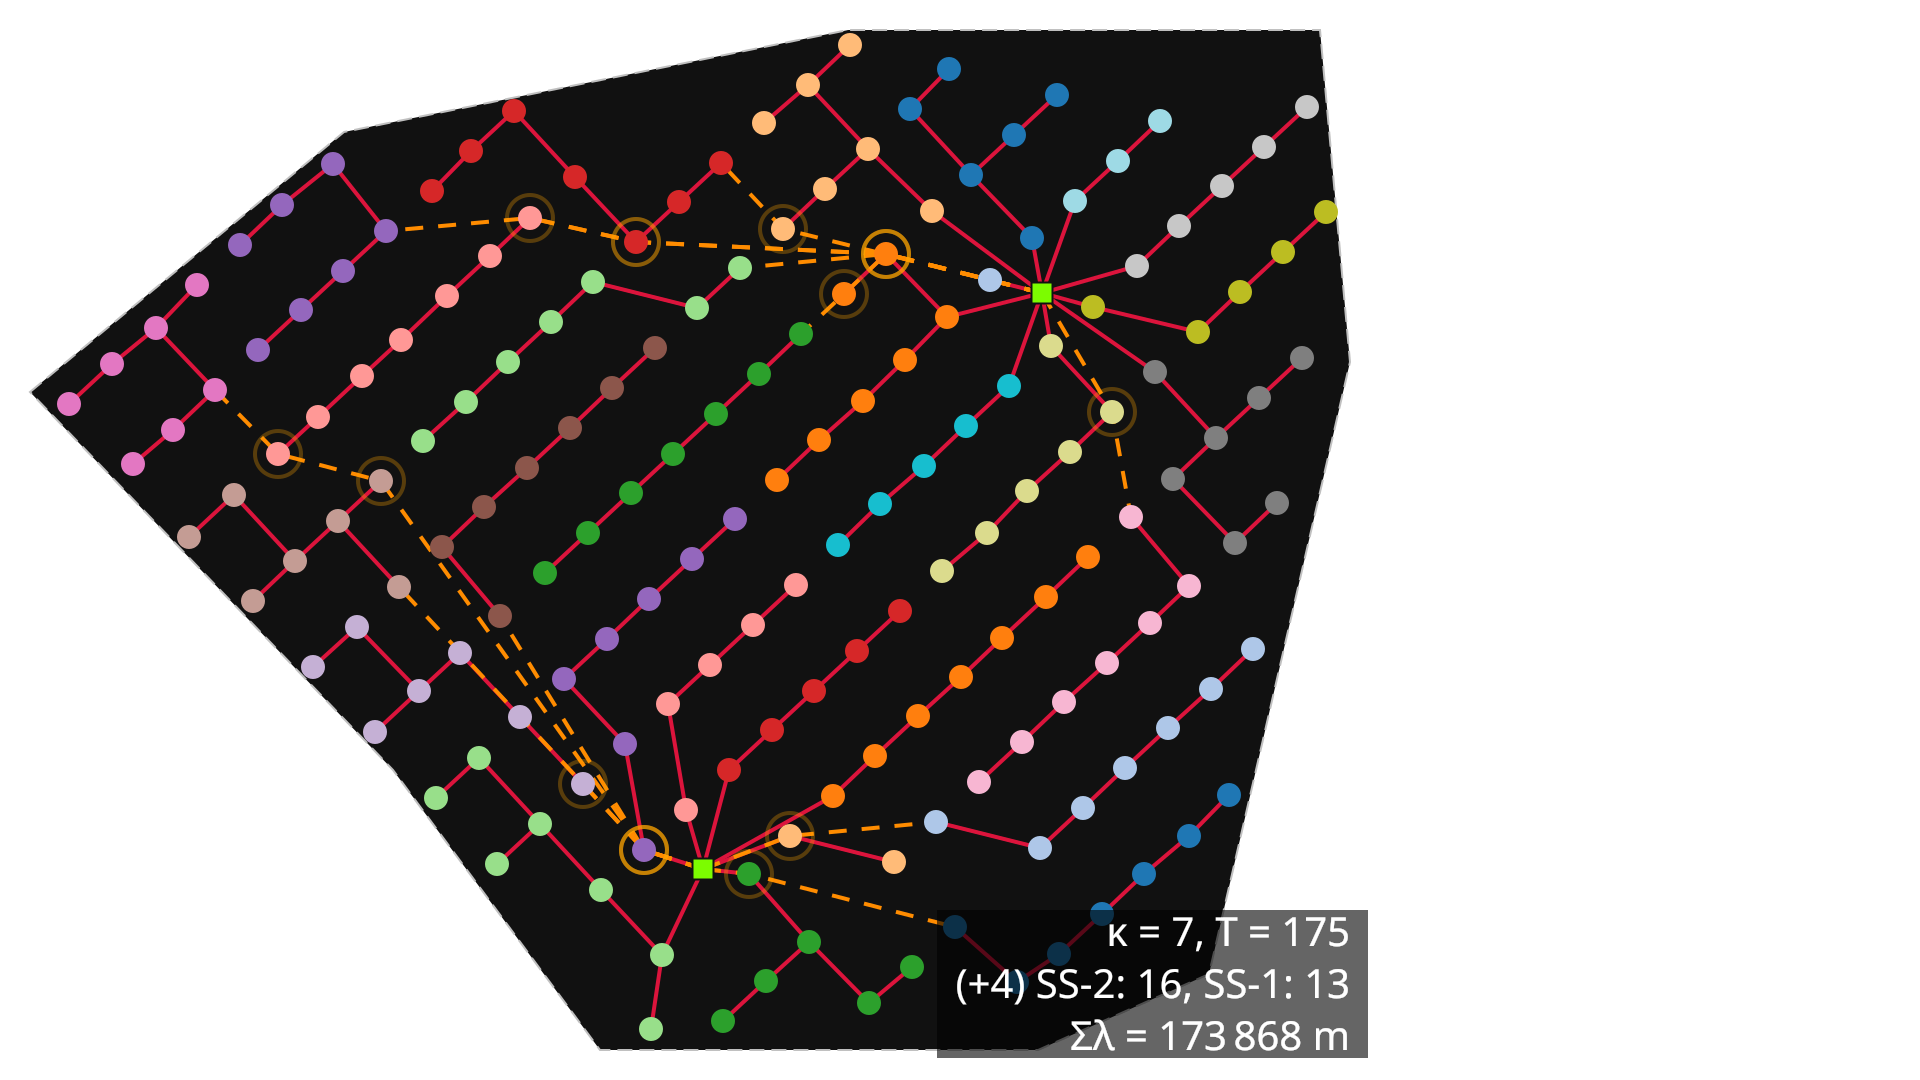

In [4]:
svgplot(G)

If `G` is assigned cable types, it is encoded in the thickness of the edges (higher capacities represented by thicker lines). The total network cost is also added to the infobox.

In [5]:
# one 2-tuple for each cable type: (capacity, linear cost)
# capacities must be increasing
assign_cables(G, cables=[(2, 400), (4, 600), (7, 900)])

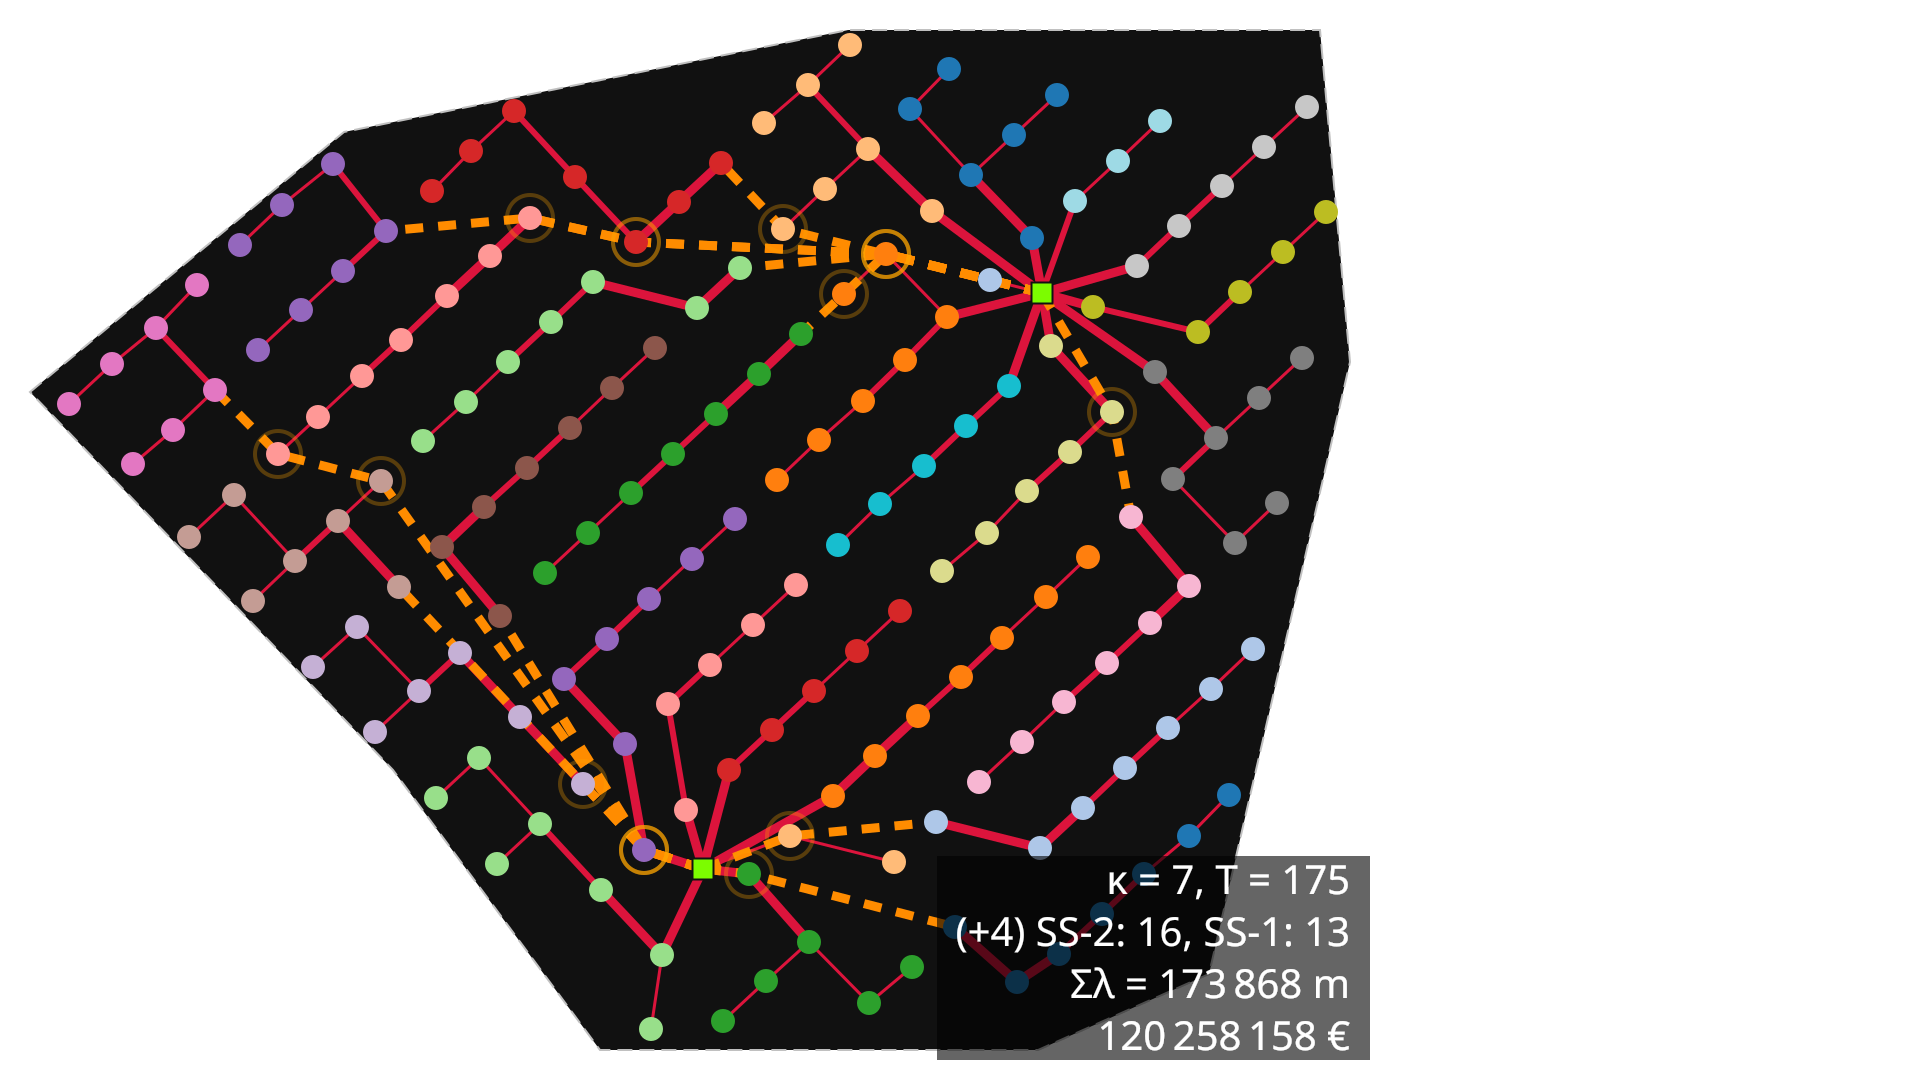

In [6]:
svgplot(G)

#### Node tags and figure legends

[svgplot()](../autoapi/optiwindnet/svg/index.rst#optiwindnet.svg.svgplot) supports a variety of node tagging options and automatic legend strip generation. The `node_tag` argument decides what is drawn inside the node symbols:

| Value | Effect |
| --- | --- |
| `True` | The node number — from order of appearance in the data, starting at `0` for terminals and negative for roots. |
| `'label'` | The node's `label` attribute, as defined in the `.yaml` or `.osm.pbf` file, or assigned programmatically. |
| `'load'` | The [load](../reference/glossary.md) exported by the node: for a terminal, the number of terminals upstream including itself; for a root, the total number of terminals connected to it. |
| `'attribute_name'` | The value of any other node attribute. |

Default symbol sizes suit tags of up to three characters; longer tags may not fit.

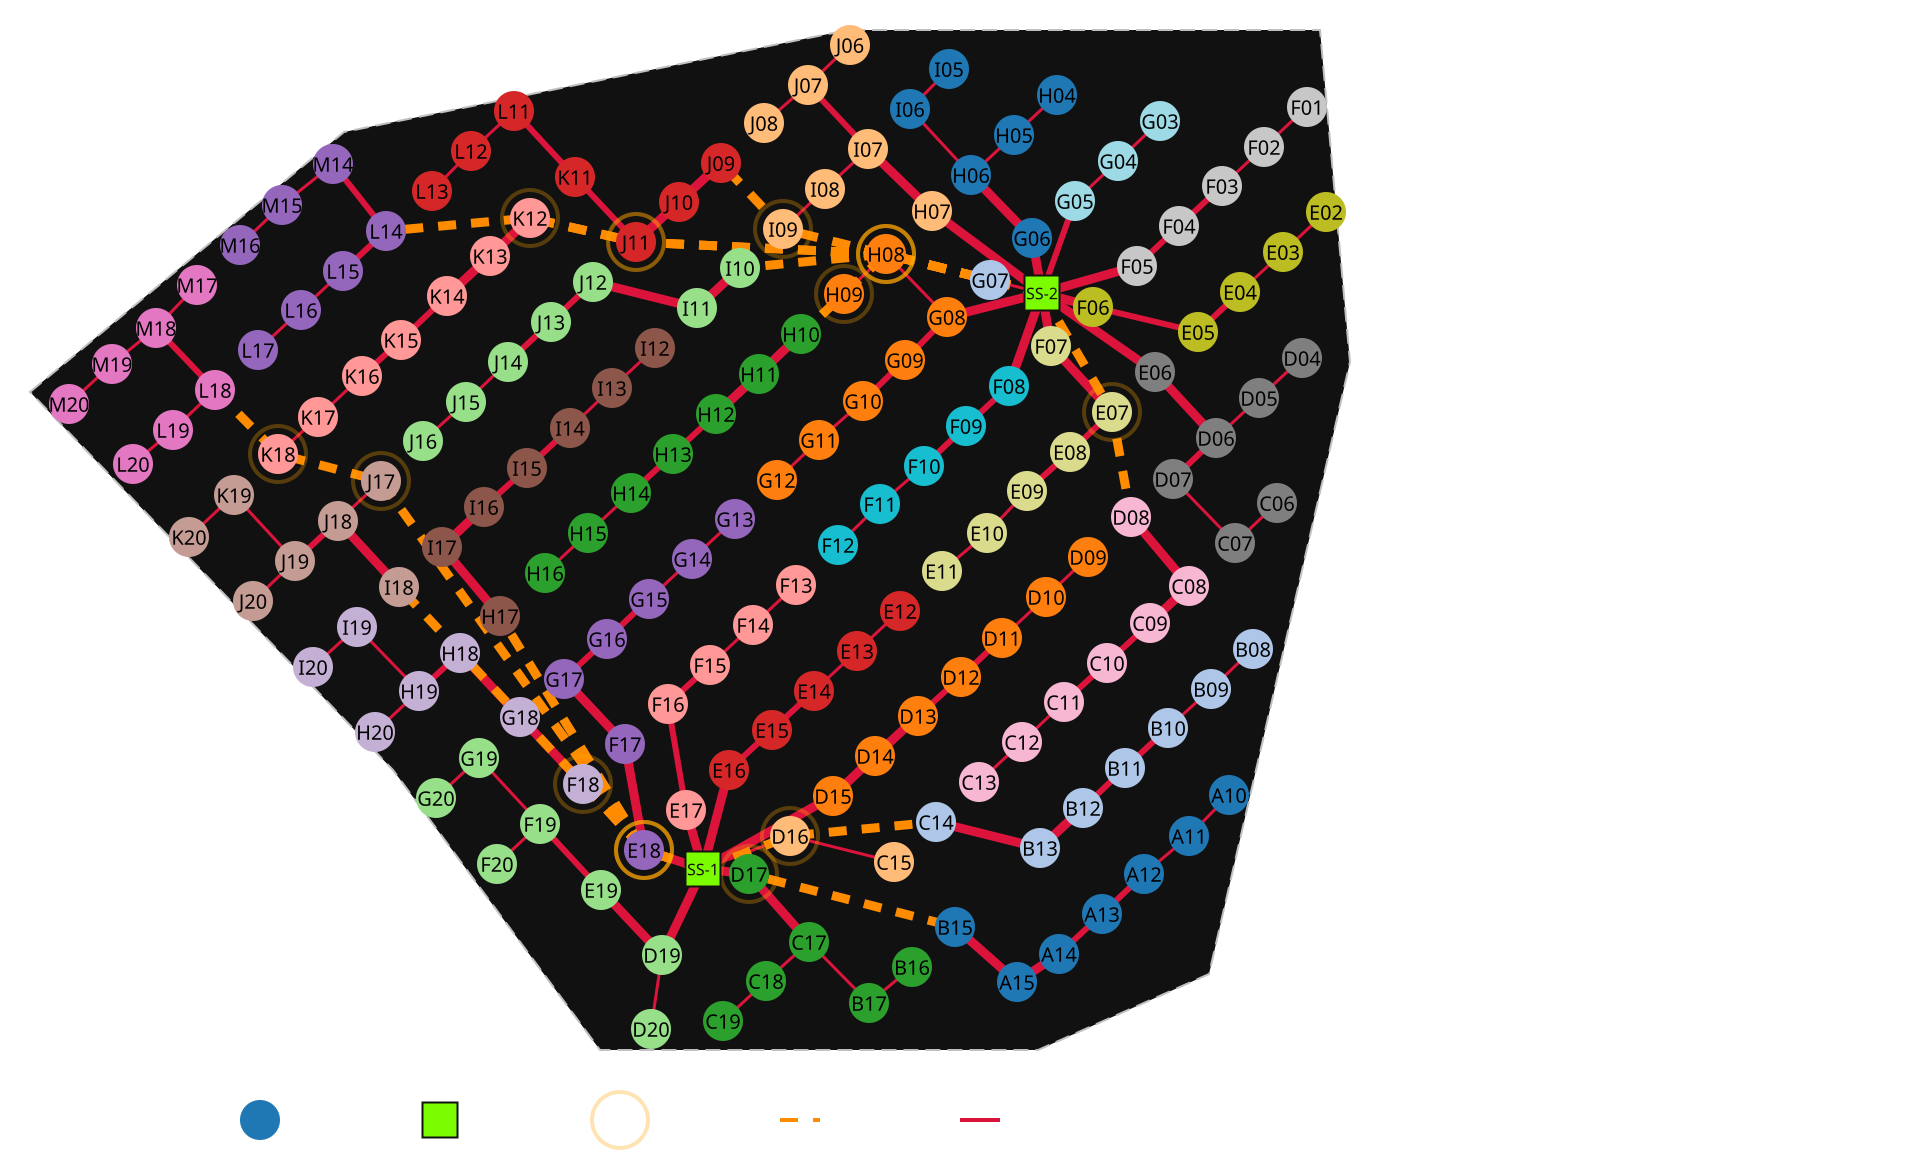

In [7]:
svgplot(G, node_tag='label', infobox=False, legend=True)

Alternatively, the internal index of the nodes can be shown instead of their labels by setting `node_tag=True`:

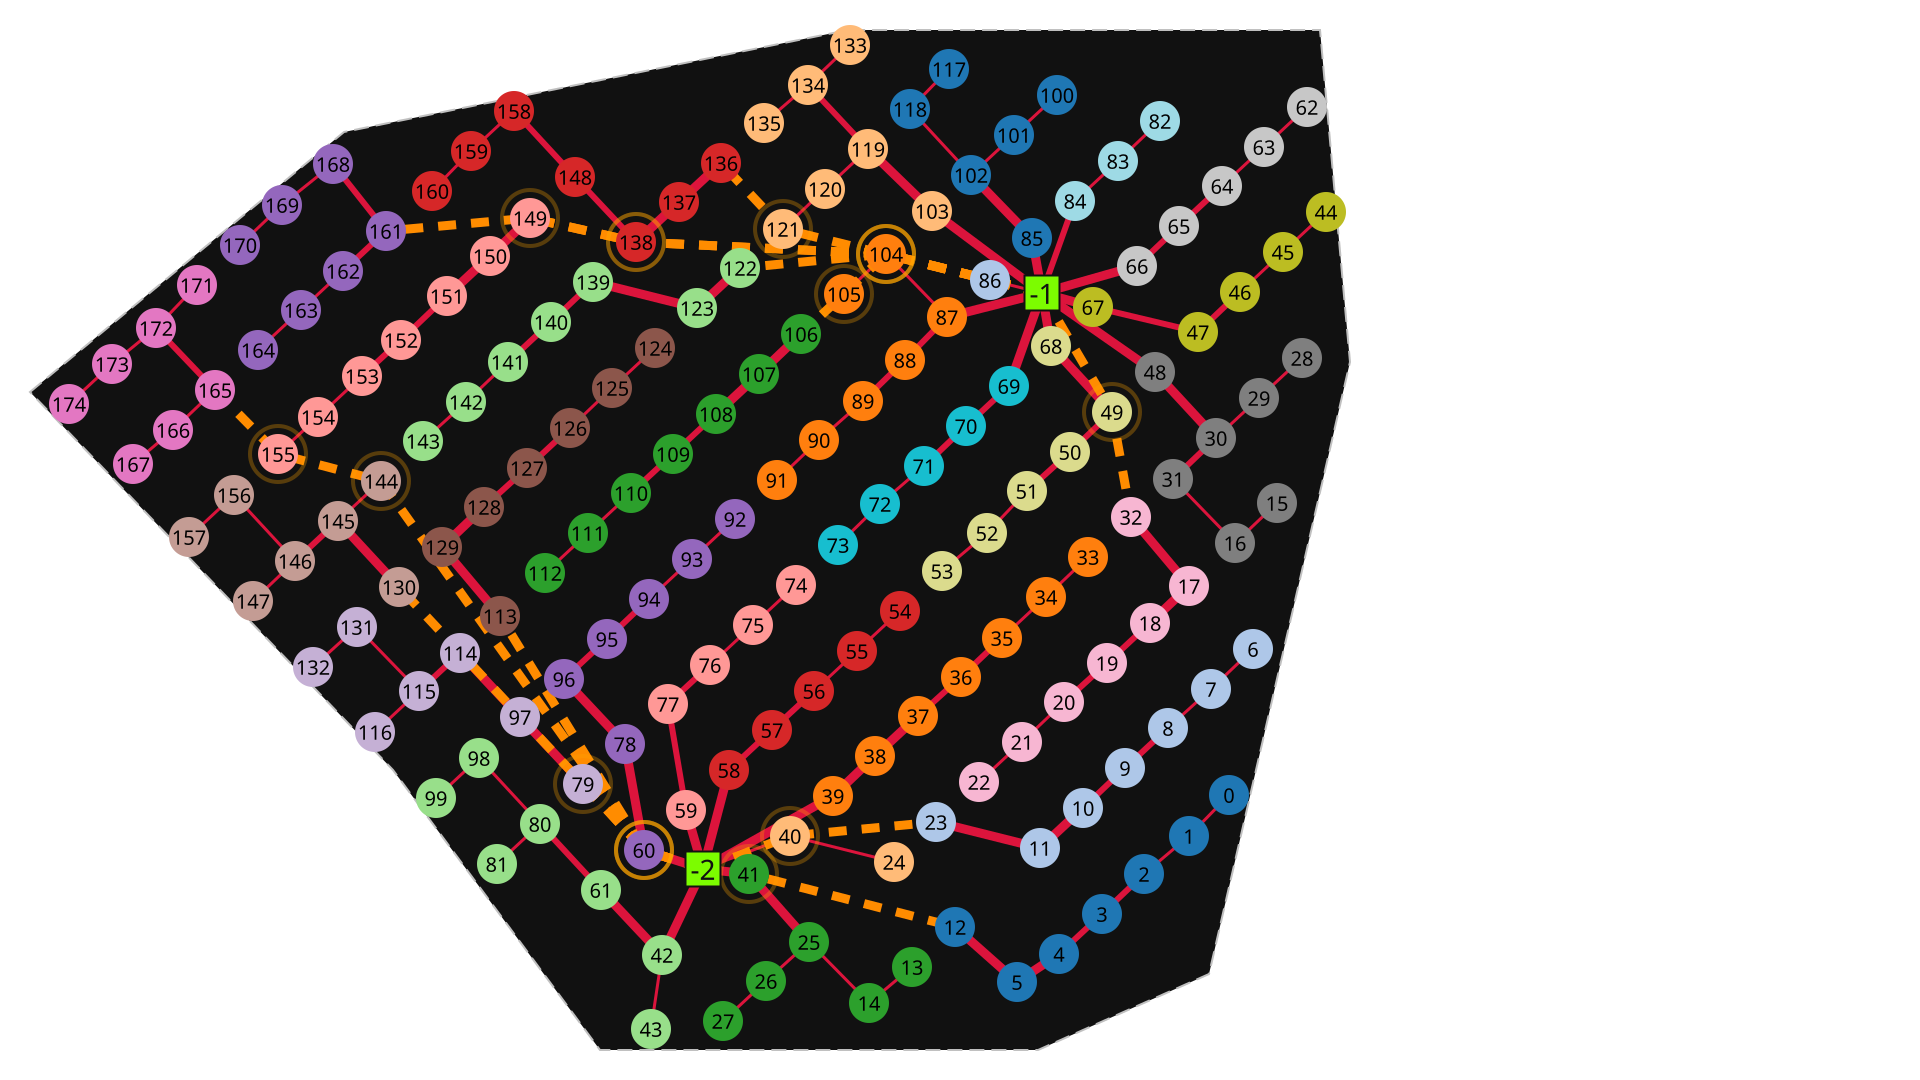

In [8]:
svgplot(G, node_tag=True, infobox=False)

The nodes can also be tagged by the power flow (load) they export towards the substation:

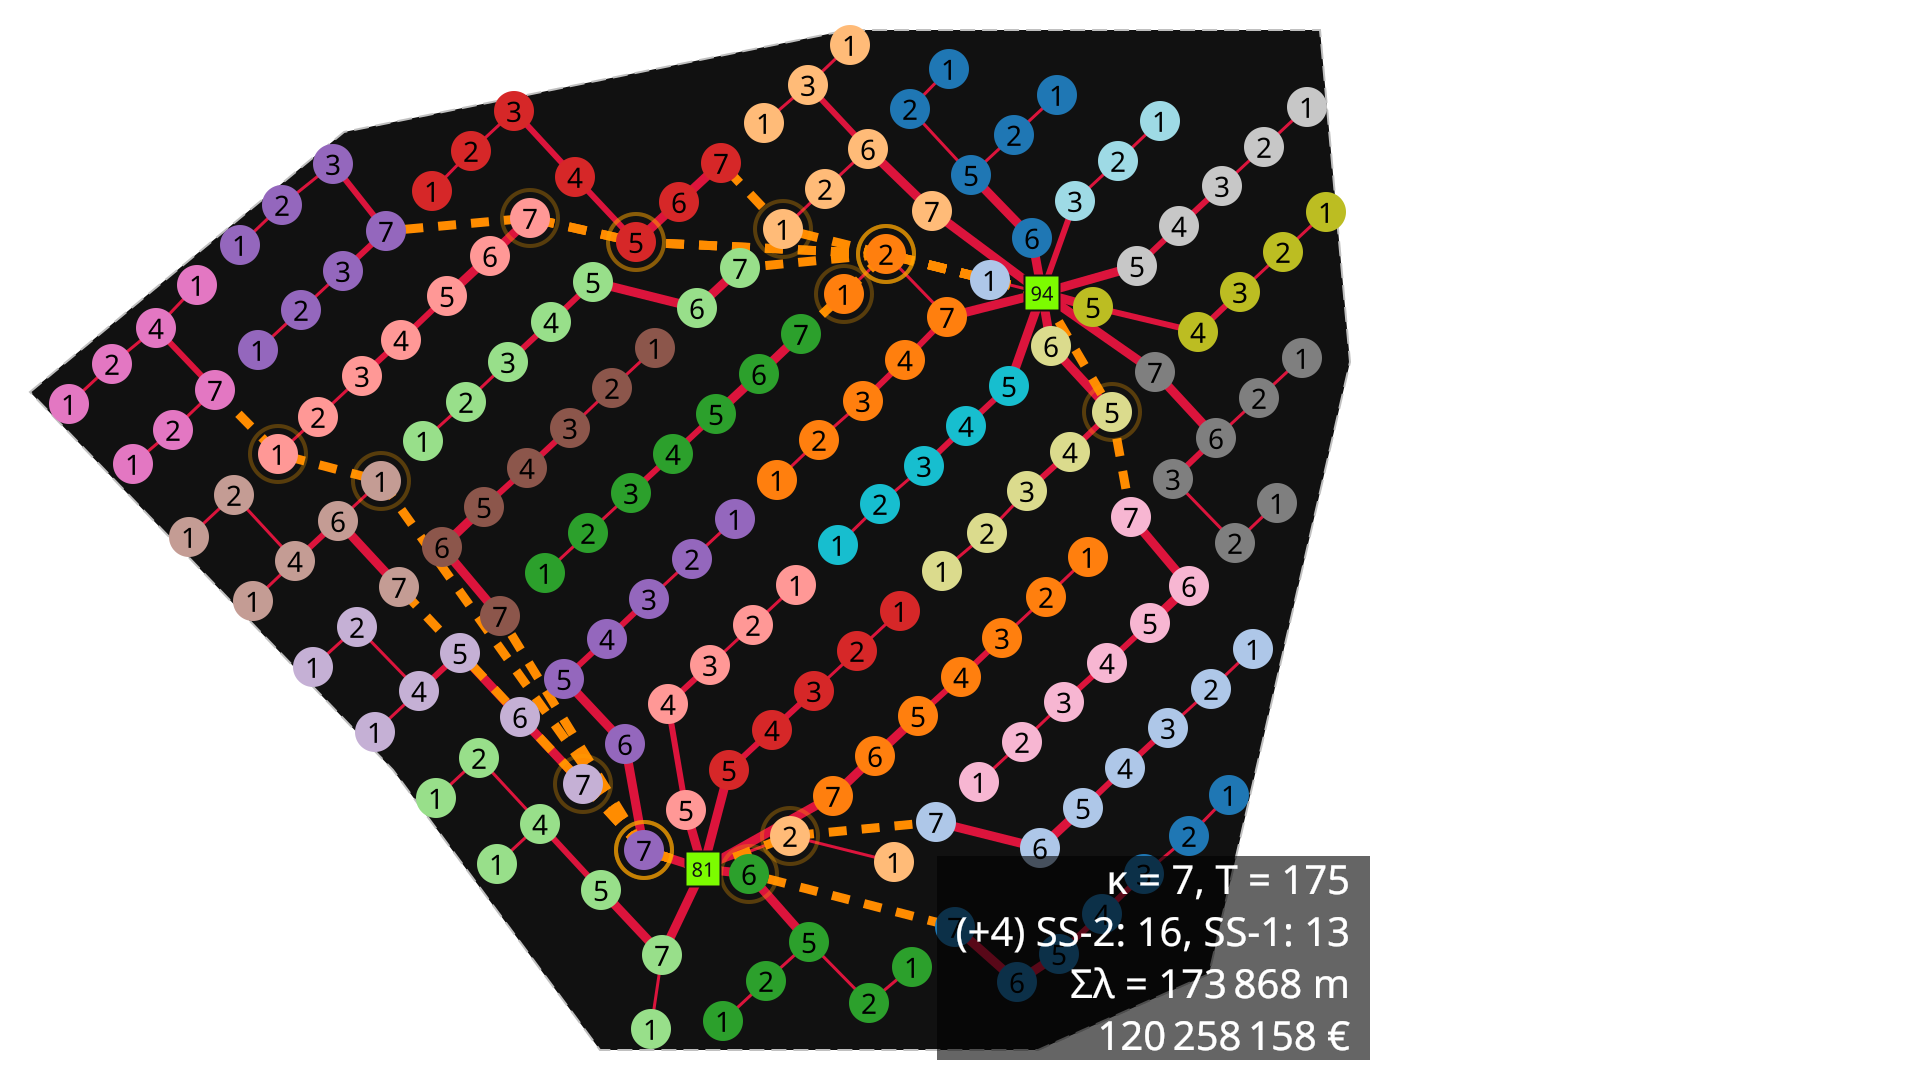

In [9]:
svgplot(G, node_tag='load')

#### Displaying in loops and saving to files

The [svgplot()](../autoapi/optiwindnet/svg/index.rst#optiwindnet.svg.svgplot) function does not create an inline image immediately upon being called; the SVG is displayed when the object returned by the call is the cell output. To display figures created within code loops, use `IPython.display.display`.

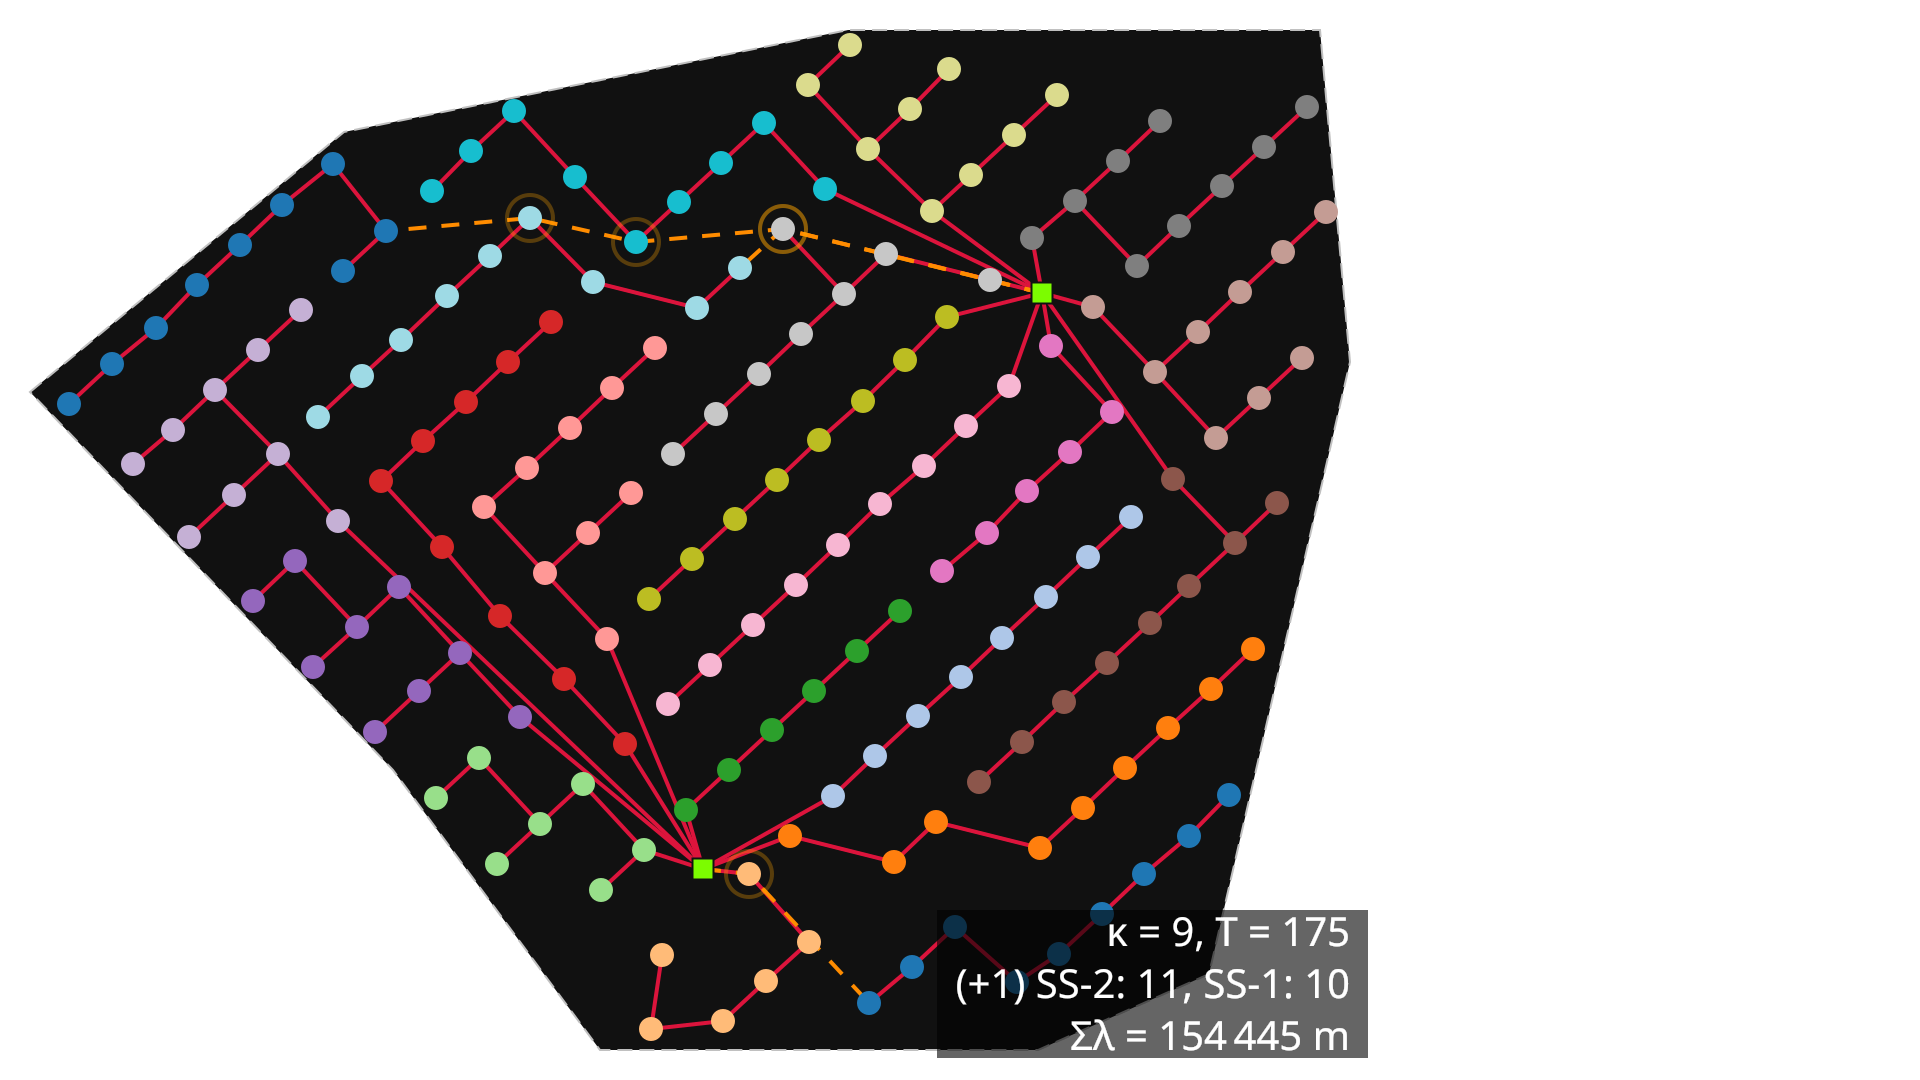

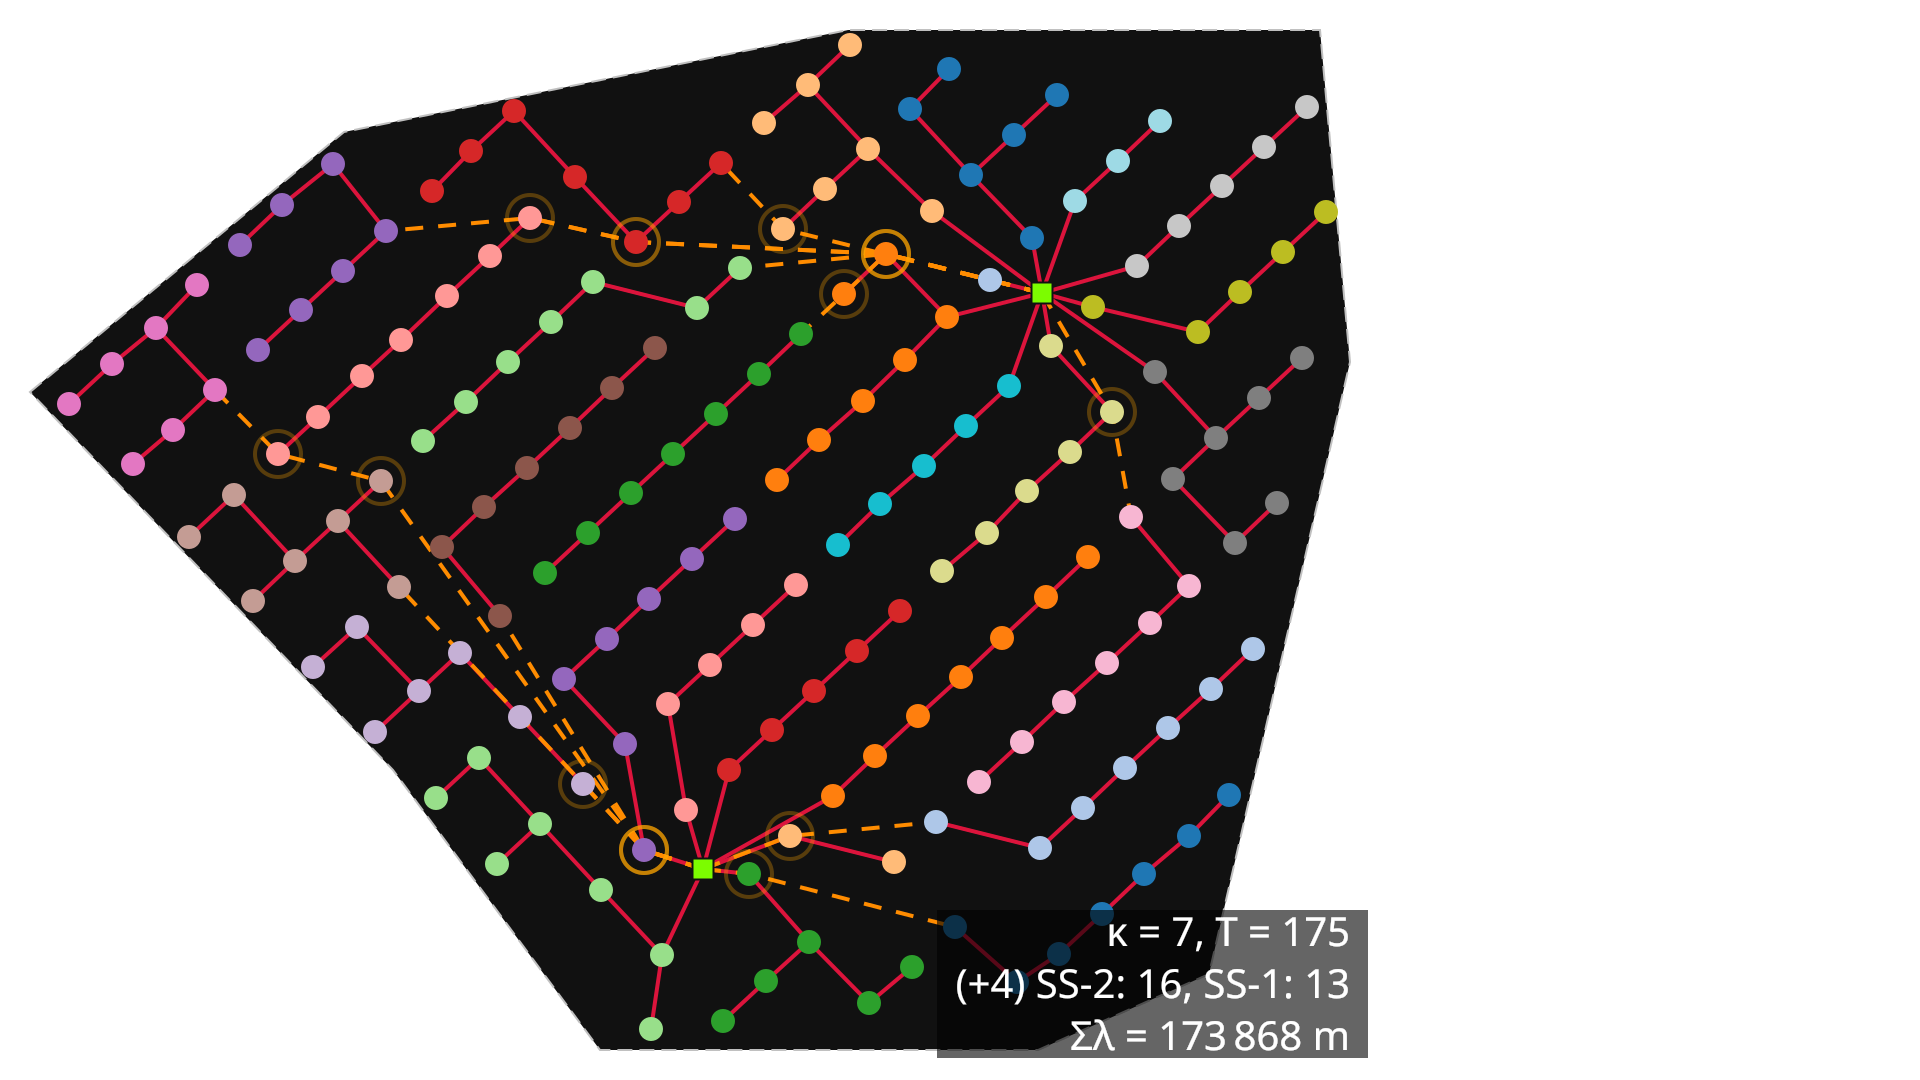

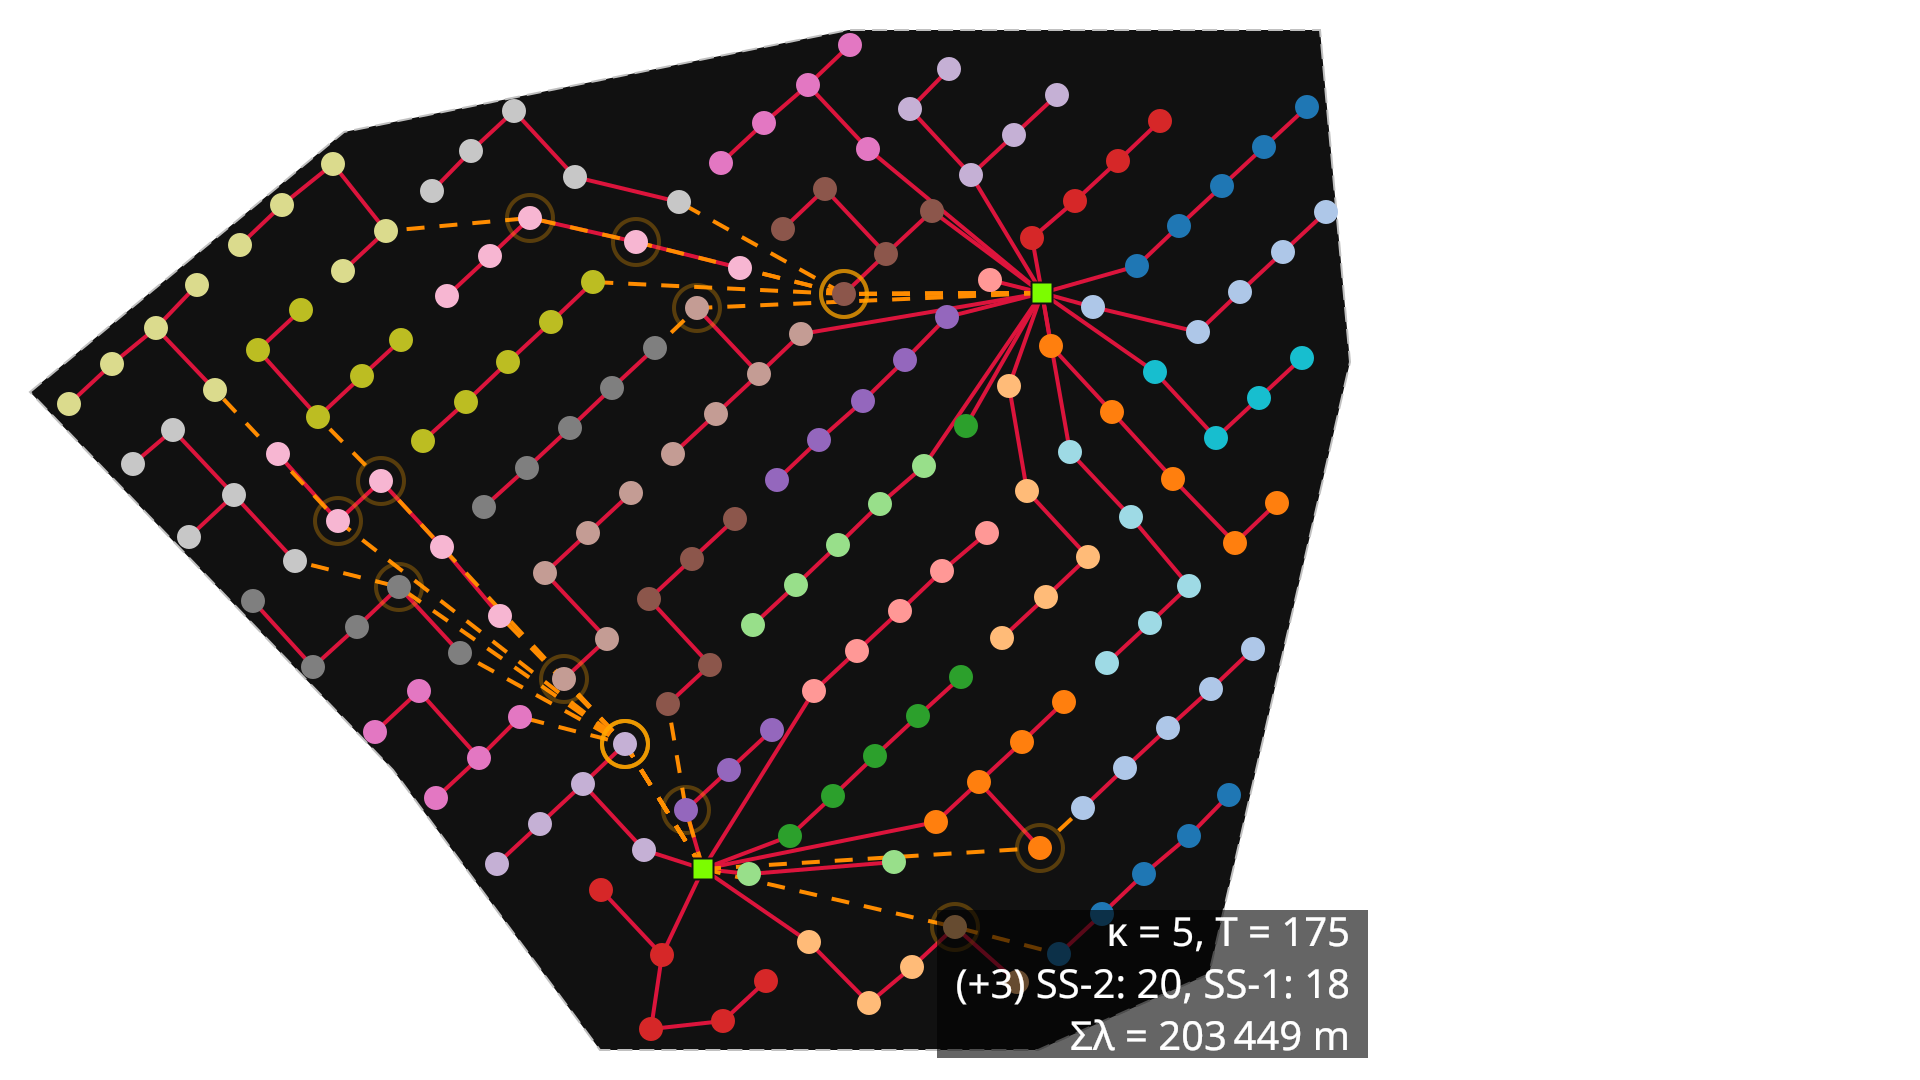

In [10]:
for cap in [9, 7, 5]:
    S_loop = constructor(A, capacity=cap)
    G_loopʹ = G_from_S(S_loop, A)
    G_loop = PathFinder(G_loopʹ, planar=P, A=A).create_detours()
    display(svgplot(G_loop))

To save an SVG representation to a file:

```python
svgplot(G).save('myfig.svg')
```

[svgplot()](../autoapi/optiwindnet/svg/index.rst#optiwindnet.svg.svgplot) automatically tries to match the operating system's theme, through the `darkdetect` package — note that this detects the _system_ theme, not JupyterLab's, so the two can disagree. To enforce a theme programmatically, set the `dark` parameter to `True` or `False`.

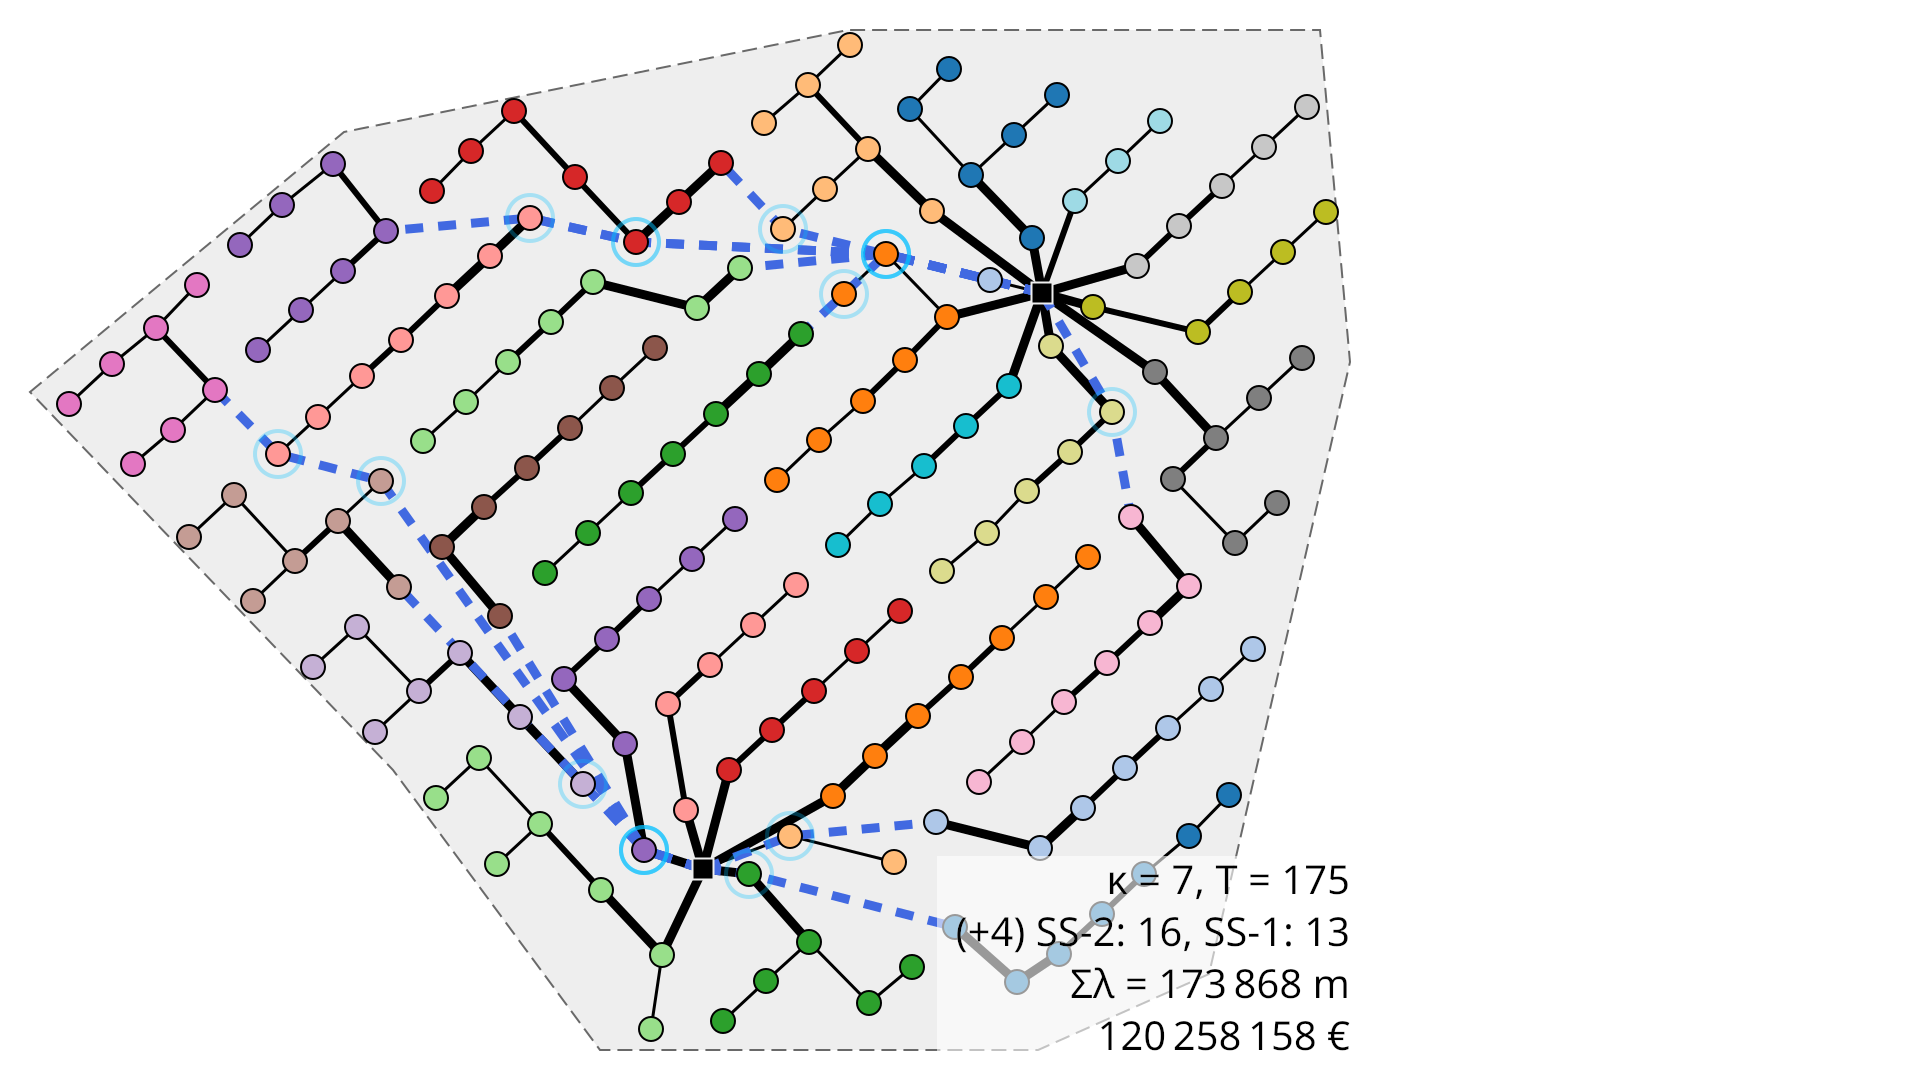

In [11]:
svgplot(G, dark=False)

Each location included in OptiWindNet has a graph attribute called `landscape_angle`. To orient the plot with north always up, set `landscape=False`.

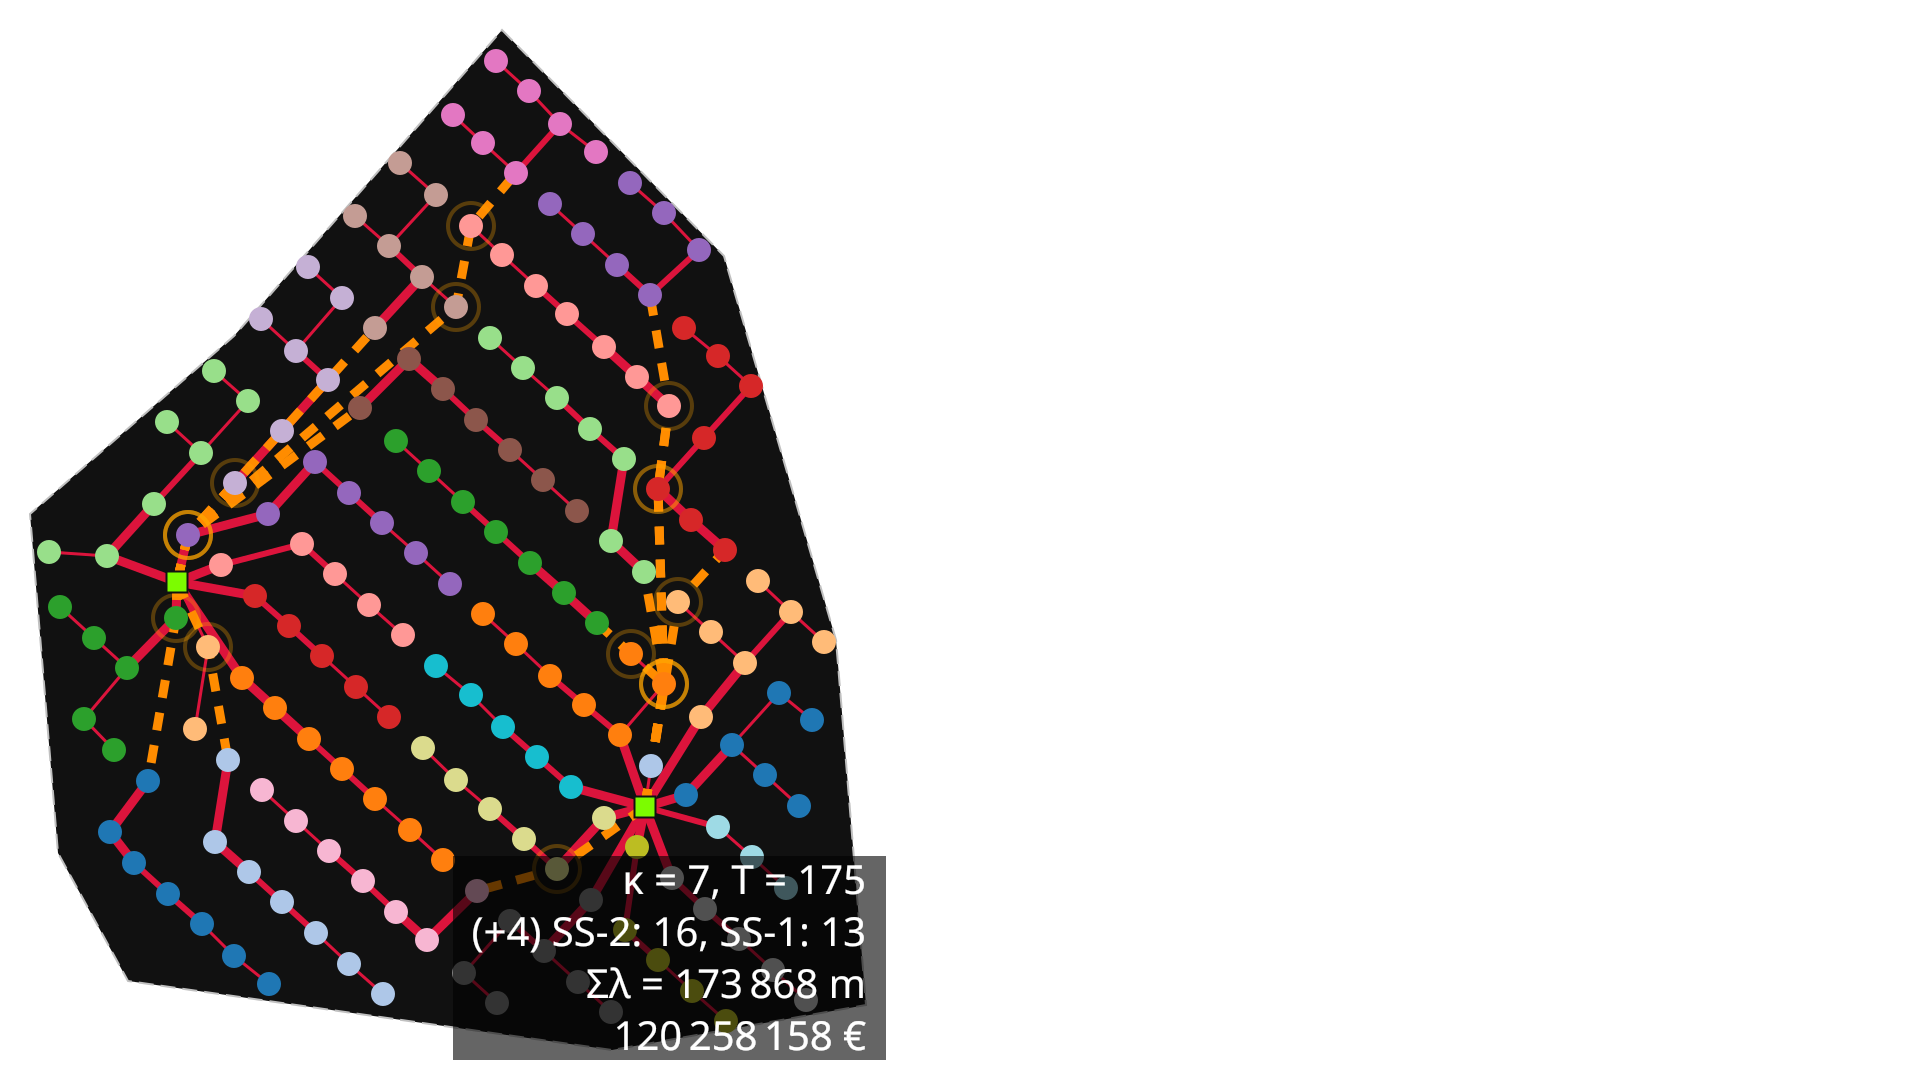

In [12]:
svgplot(G, landscape=False)

### Using Matplotlib-based `gplot()` & `pplot()`

OptiWindNet also provides Matplotlib-based plotting functions, [gplot()](../autoapi/optiwindnet/plotting/index.rst#optiwindnet.plotting.gplot) and [pplot()](../autoapi/optiwindnet/plotting/index.rst#optiwindnet.plotting.pplot), under `optiwindnet.plotting`.

While SVG-based plots are recommended for direct notebook displays, the Matplotlib-based functions are essential when you want to take advantage of Matplotlib-specific capabilities, such as multi-axis plotting and advanced custom layout integrations.

In [13]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']
plt.rcParams['svg.fonttype'] = 'none'
from optiwindnet.plotting import gplot, pplot

#### 1. Custom Multi-Axis Subplots

You can pass a pre-existing `plt.Axes` object to place plots side-by-side or integrate them inside more complex subplots:

<Axes: >

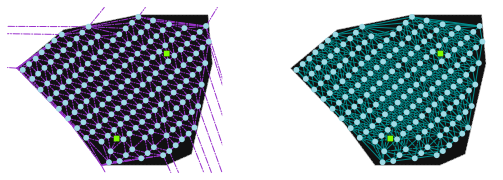

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, facecolor='none', figsize=(9, 3))
pplot(P, A, ax=ax1)
gplot(A, ax=ax2)

`pplot(P, A)` is useful for visualizing the pathfinding triangulation mesh and available edges graph `A` for debugging geometry.

#### 2. Matplotlib Axes Customization and Saving

[gplot()](../autoapi/optiwindnet/plotting/index.rst#optiwindnet.plotting.gplot) returns a standard `plt.Axes` object. You can use it to adjust any aspect of the figure or to save it directly using Matplotlib backends (such as exporting to PDF, PNG, or EPS formats):

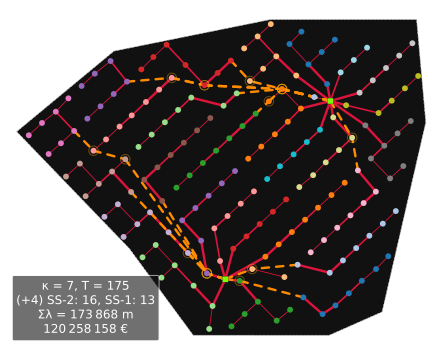

In [15]:
ax = gplot(G)
# ax.figure.savefig('myfig.pdf')